In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.append("../")

from simulations.wrapper import simulator
from utils import create_mask as cm
from utils.templates import get_NFW2_template
from models.psf import KingPSF

In [45]:
kp = KingPSF()

# Load standard templates
temp_gce = np.load("../data/fermi_data/template_gce.npy")
temp_dif = np.load("../data/fermi_data/template_dif.npy")
temp_psc = np.load("../data/fermi_data/template_psc.npy")
temp_iso = np.load("../data/fermi_data/template_iso.npy")
temp_dsk = np.load("../data/fermi_data/template_dsk.npy")
temp_bub = np.load("../data/fermi_data/template_bub.npy")

# Load exposure
fermi_exp = np.load("../data/fermi_data/fermidata_exposure.npy")

# Rescaling factor to remove exposure from PS templates
rescale = fermi_exp / np.mean(fermi_exp)

# Load Model O templates
temp_mO_pibrem = np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy")
temp_mO_ics = np.load("../data/fermi_data/ModelO_r25_q1_ics.npy")

In [111]:
prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
            [1.5, 20.0, 1.99, 1.99, 40.0, 4.99, 1.5, 20.0, 1.99, 1.99, 40.0, 4.99]]

prior_poiss = [[0.001, 0.001, 0.001, 0.001, 6.0, 1.0], 
               [1.5, 1.5, 1.5, 1.5, 12.0, 6.0]]

In [167]:
n_sim = 100

In [168]:
thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

In [169]:
temps_poiss = [temp_gce, temp_iso, temp_bub, temp_psc, temp_mO_pibrem, temp_mO_ics]
temps_ps = [temp_gce, temp_dsk]

In [170]:
nside = 128

# Get mask of central pixel for nside=1
hp_mask_nside1 = cm.make_mask_total(nside=1, band_mask=True, band_mask_range=0, mask_ring=True, inner=0, outer=30.)

# Get mask corresponding to nside=128
mask_sim = hp.ud_grade(hp_mask_nside1, nside)

# ROI to normalize counts over
mask_normalize_counts = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2, mask_ring=True, inner=0, outer=30.0)

mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2, mask_ring=True, inner=0, outer=25.)

In [171]:
from tqdm.notebook import tqdm

In [172]:
import multiprocessing

multiprocessing.cpu_count()

32

In [139]:
[simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, kp.psf_fermi_r, fermi_exp) for theta in tqdm(thetas)];

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
mask_sim = np.zeros(hp.nside2npix(nside)).astype(np.bool)

In [ ]:
from multiprocessing import Pool

def simulate_map(theta):
    return simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, kp.psf_fermi_r, fermi_exp)
    
pool = Pool()                         
simulated_maps = tqdm(pool.imap(simulate_map, thetas))

In [158]:
simulated_maps[0].shape

(1, 196608)

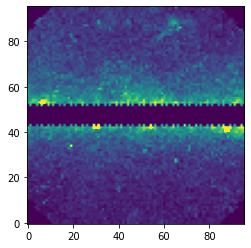

In [165]:
from functools import partial

lonra = [-20, 20]
latra = [-20, 20]

n_pixels = 96

proj = hp.projector.CartesianProj(lonra=lonra, latra=latra, coord='G', xsize=n_pixels, ysize=n_pixels)
temp_dif_cart = proj.projmap(simulated_maps[0][0], vec2pix_func=partial(hp.vec2pix, nside))

plt.imshow(temp_dif_cart, vmax=100., origin='lower')

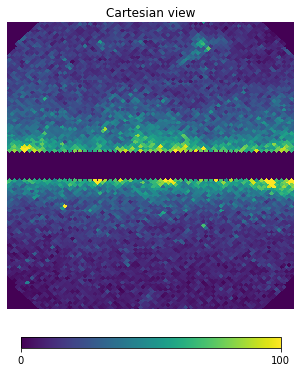

In [164]:
hp.cartview(simulated_maps[0][0], lonra=lonra, latra=latra, max=100.)